In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utility import *
from tools import *
from maps import *
from scipy.stats import linregress
from scipy.ndimage import maximum_filter, label
from scipy.spatial.distance import pdist, squareform

In [2]:
index = []

with open('C:/Users/Kevin/Desktop/26-02-24/01_01_01_location.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        index.append(np.array(numbers, dtype=int))

index = np.array(index)

latency = []

with open('C:/Users/Kevin/Desktop/26-02-24/01_01_01_latency.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        latency.append(np.array(numbers, dtype=float))
        
latency = np.array(latency)

In [3]:
index_Q = []

with open('C:/Users/Kevin/Desktop/26-02-24/01_01_03_location.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        index_Q.append(np.array(numbers, dtype=int))

index_Q = np.array(index_Q)

latency_Q = []

with open('C:/Users/Kevin/Desktop/26-02-24/01_01_03_latency.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        latency_Q.append(np.array(numbers, dtype=float))
        
latency_Q = np.array(latency_Q)

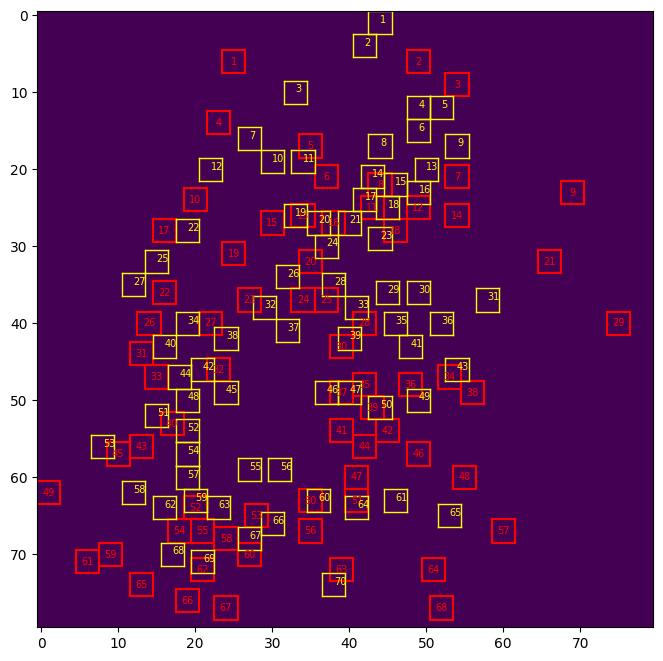

In [4]:
background = np.ones((80, 80))

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(background)

for i, coor in enumerate(index):
    
    r = coor[1]
    c = coor[0]
    
    top = r - 1.5
    bottom = r + 1.5
    left = c - 1.5
    right = c + 1.5

    ax.plot([top, top], [left, right], color='red', linewidth=1.5)
    ax.plot([bottom, bottom], [left, right], color='red', linewidth=1.5)
    ax.plot([top, bottom], [left, left], color='red', linewidth=1.5)
    ax.plot([top, bottom], [right, right], color='red', linewidth=1.5)
    ax.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='red')

for i, coor in enumerate(index_Q):
    
    r = coor[1]
    c = coor[0]
    
    top = r - 1.5
    bottom = r + 1.5
    left = c - 1.5
    right = c + 1.5

    ax.plot([top, top], [left, right], color='yellow', linewidth=1)
    ax.plot([bottom, bottom], [left, right], color='yellow', linewidth=1)
    ax.plot([top, bottom], [left, left], color='yellow', linewidth=1)
    ax.plot([top, bottom], [right, right], color='yellow', linewidth=1)
    ax.annotate(str(i+1), xy=(r, c), fontsize=7, color='yellow')
    
plt.show()

Neuron 52 and Neuron 4 are correlated with a positive slope, and the P-Value is: 0.007489 , distance is: 300.53951487283666 um.
Neuron 52 and Neuron 15 are correlated with a positive slope, and the P-Value is: 0.010144 , distance is: 229.9652147608416 um.
Neuron 52 and Neuron 37 are correlated with a positive slope, and the P-Value is: 0.016157 , distance is: 145.24462124292245 um.
Neuron 52 and Neuron 39 are correlated with a positive slope, and the P-Value is: 0.000192 , distance is: 158.51813776347487 um.
Neuron 52 and Neuron 47 are correlated with a positive slope, and the P-Value is: 0.028724 , distance is: 128.26534995859168 um.
Neuron 52 and Neuron 53 are correlated with a positive slope, and the P-Value is: 0.02641 , distance is: 48.373546489791295 um.


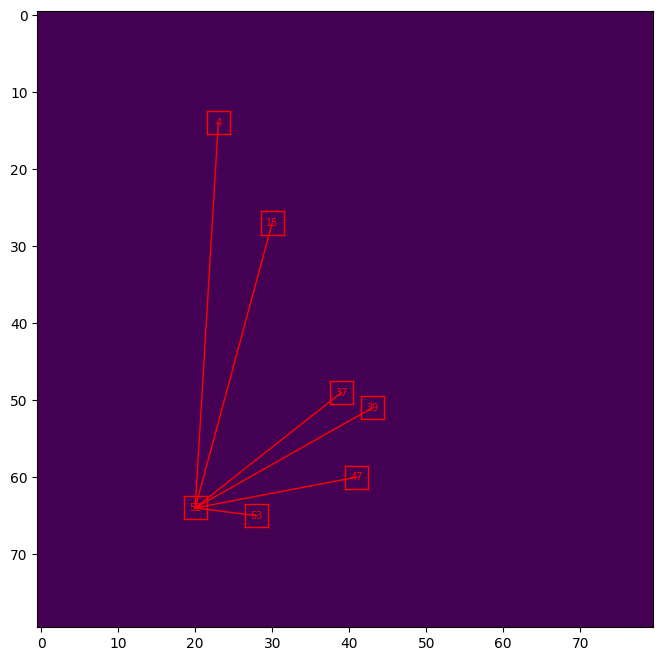

In [5]:
# Slice without Quinine.
neuro_label = 52
count = 0

background = np.ones((80, 80))
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(background)
top = index[neuro_label-1][1] - 1.5
bottom = index[neuro_label-1][1] + 1.5
left = index[neuro_label-1][0] - 1.5
right = index[neuro_label-1][0] + 1.5

ax.plot([top, top], [left, right], color='red', linewidth=1)
ax.plot([bottom, bottom], [left, right], color='red', linewidth=1)
ax.plot([top, bottom], [left, left], color='red', linewidth=1)
ax.plot([top, bottom], [right, right], color='red', linewidth=1)
ax.annotate(str(neuro_label), xy=(index[neuro_label-1][1], index[neuro_label-1][0]), ha='center', va='center', fontsize=7, color='red')

for i in range(len(index)):

    if i == neuro_label - 1:
        continue
    else:
        dist = np.sqrt((index[i][0] - index[neuro_label-1][0])**2 + (index[i][1] - index[neuro_label-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[neuro_label-1])

        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', neuro_label, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            
            loc_1 = index[i]
            loc_2 = index[neuro_label-1]

            ax.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax.plot([top, top], [left, right], color='red', linewidth=1)
            ax.plot([bottom, bottom], [left, right], color='red', linewidth=1)
            ax.plot([top, bottom], [left, left], color='red', linewidth=1)
            ax.plot([top, bottom], [right, right], color='red', linewidth=1)
            ax.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='red')

plt.show()

Neuron 59 and Neuron 51 are correlated with a positive slope, and the P-Value is: 0.02265 , distance is: 72.49827584156743 um.
Neuron 59 and Neuron 70 are correlated with a positive slope, and the P-Value is: 0.046326 , distance is: 126.57013865837393 um.


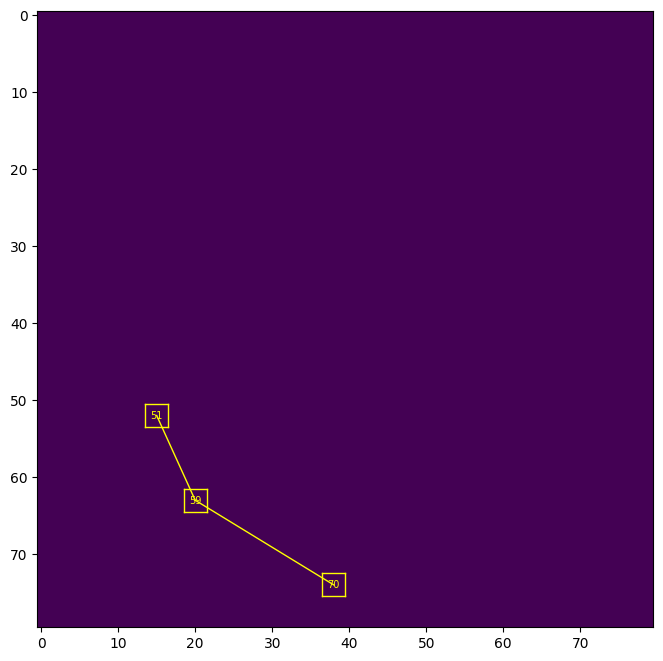

In [6]:
# Slice with Quinine.
neuro_label = 59
count = 0

background = np.ones((80, 80))
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(background)
top = index_Q[neuro_label-1][1] - 1.5
bottom = index_Q[neuro_label-1][1] + 1.5
left = index_Q[neuro_label-1][0] - 1.5
right = index_Q[neuro_label-1][0] + 1.5

ax.plot([top, top], [left, right], color='yellow', linewidth=1)
ax.plot([bottom, bottom], [left, right], color='yellow', linewidth=1)
ax.plot([top, bottom], [left, left], color='yellow', linewidth=1)
ax.plot([top, bottom], [right, right], color='yellow', linewidth=1)
ax.annotate(str(neuro_label), xy=(index_Q[neuro_label-1][1], index_Q[neuro_label-1][0]), ha='center', va='center', fontsize=7, color='yellow')

for i in range(len(index_Q)):

    if i == neuro_label - 1:
        continue
    else:
        dist = np.sqrt((index_Q[i][0] - index_Q[neuro_label-1][0])**2 + (index_Q[i][1] - index_Q[neuro_label-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_Q[i], latency_Q[neuro_label-1])

        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', neuro_label, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            
            loc_1 = index_Q[i]
            loc_2 = index_Q[neuro_label-1]

            ax.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='yellow', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax.plot([top, top], [left, right], color='yellow', linewidth=1)
            ax.plot([bottom, bottom], [left, right], color='yellow', linewidth=1)
            ax.plot([top, bottom], [left, left], color='yellow', linewidth=1)
            ax.plot([top, bottom], [right, right], color='yellow', linewidth=1)
            ax.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='yellow')

plt.show()

In [ ]:
num = len(index)
trial = latency.shape[1]
count = 0
PValue = []
Distance = []

for i in range(num-1):
    for j in range(i+1, num):
        
        dist = np.sqrt((index[i][0] - index[j][0])**2 + (index[i][1] - index[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            PValue.append(pValue)
            Distance.append(dist)
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')

print(count, 'pairs are correlated.')
print('Totally', int(num*(num-1)/2), 'pairs.')
PValue = np.array(PValue)
Distance = np.array(Distance)

In [ ]:
Slope, _, _, pValue, _ = linregress(Distance, PValue)
print('P-Value is : {}, Slope is: {}.'.format(pValue, Slope))

plt.scatter(Distance, PValue)
plt.show()

In [ ]:
num = len(index_Q)
trial = latency_Q.shape[1]
count = 0
PValue_Q = []
Distance_Q = []

for i in range(num-1):
    for j in range(i+1, num):
        
        dist = np.sqrt((index_Q[i][0] - index_Q[j][0])**2 + (index_Q[i][1] - index_Q[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_Q[i], latency_Q[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            PValue_Q.append(pValue)
            Distance_Q.append(dist)
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')

print(count, 'pairs are correlated.')
print('Totally', int(num*(num-1)/2), 'pairs.')
PValue_Q = np.array(PValue_Q)
Distance_Q = np.array(Distance_Q)

In [ ]:
Slope, _, _, pValue, _ = linregress(Distance_Q, PValue_Q)
print('P-Value is : {}, Slope is: {}.'.format(pValue, Slope))
plt.scatter(Distance_Q, PValue_Q)
plt.show()